In [17]:
# apply the data wraggling
import pandas as pd
df=pd.read_csv("googl_daily_prices.csv", encoding="ISO-8859-1")

In [18]:
# to see the first five row and columns of dataset
df.head()

,date,1. open,2. high,3. low,4. close,5. volume
0,2025-06-06,170.830,174.500,170.83,173.68,35731832.0
1,2025-06-05,170.340,170.930,167.59,168.21,36444564.0
2,2025-06-04,166.735,168.215,166.36,168.05,26900838.0
3,2025-06-03,167.490,168.475,165.28,166.18,45084903.0
4,2025-06-02,167.840,169.870,167.39,169.03,38612272.0


In [19]:
#2) konwing what type of the stattistics summary dataset is containing
df.describe()

,1. open,2. high,3. low,4. close,5. volume
count,5234.000000,5234.000000,5234.000000,5234.000000,5.234000e+03
mean,763.907720,771.526626,755.902277,763.849942,9.772941e+06
std,612.952378,619.071344,606.418682,612.876624,1.209103e+07
min,85.400000,86.520000,83.340000,83.430000,4.656380e+05
25%,396.895000,404.455000,392.237500,396.977500,1.814807e+06
50%,585.260000,588.885000,578.955000,583.730000,4.575191e+06
75%,998.410000,1007.380000,991.137575,1000.770000,1.314940e+07
max,3025.000000,3030.931500,2977.980000,2996.770000,1.277476e+08


In [20]:
#3) to knowing the structure of the dataset
df.info()  # also tell the non null vakue per columns 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5234 entries, 0 to 5233
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       5234 non-null   object 
 1   1. open    5234 non-null   float64
 2   2. high    5234 non-null   float64
 3   3. low     5234 non-null   float64
 4   4. close   5234 non-null   float64
 5   5. volume  5234 non-null   float64
dtypes: float64(5), object(1)
memory usage: 245.5+ KB


In [21]:
#4) to know the missing value in the dataset
df.isnull().sum()
# result: know i can conculde that there is now missing value in my dataset

date         0
1. open      0
2. high      0
3. low       0
4. close     0
5. volume    0
dtype: int64

In [22]:
#5) to know is there any duplication row in the dataset
df.duplicated().sum()


0

In [23]:
#6)  
df.rename(columns={
    '1. open' : 'Open',
    '2. high' : 'High',
    '3. low'  : 'Low',
    '4. close' : 'Close',
    '5. volume' : 'Volume'
},inplace=True) 
df
# here i am using inplace true bcz i wnat to directly convert dataset without copying it

,date,Open,High,Low,Close,Volume
0,2025-06-06,170.830,174.500,170.83,173.680,35731832.0
1,2025-06-05,170.340,170.930,167.59,168.210,36444564.0
2,2025-06-04,166.735,168.215,166.36,168.050,26900838.0
3,2025-06-03,167.490,168.475,165.28,166.180,45084903.0
4,2025-06-02,167.840,169.870,167.39,169.030,38612272.0
...,...,...,...,...,...,...
5229,2004-08-25,104.760,108.000,103.88,106.000,9188600.0
5230,2004-08-24,111.240,111.600,103.57,104.870,15247300.0
5231,2004-08-23,110.760,113.480,109.05,109.400,18256100.0
5232,2004-08-20,101.010,109.080,100.50,108.310,22834300.0


In [24]:
# 8): converting  date column it in to real date format 
df["date"]=pd.to_datetime(df["date"])
print(df["date"].dtype)
# result: as it is first read the date columns as object in pandas and  now convert it in convert in real date format  

datetime64[ns]


In [25]:
#7) extract info from from the date columns
 #Convert 'date' column to datetime


df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"]= df["date"].dt.day
df["weekday"]=df["date"].dt.day_name()
print(df[['date','year','month','day','weekday']].head())


        date  year  month  day    weekday
0 2025-06-06  2025      6    6     Friday
1 2025-06-05  2025      6    5   Thursday
2 2025-06-04  2025      6    4  Wednesday
3 2025-06-03  2025      6    3    Tuesday
4 2025-06-02  2025      6    2     Monday


In [26]:
#9) to tell gain or lose on every day
df["Price_change"]=df["Close"]-df["Open"]
df
#result:this tell how much the stock price go up and down on regular days 

,date,Open,High,Low,Close,Volume,year,month,day,weekday,Price_change
0,2025-06-06,170.830,174.500,170.83,173.680,35731832.0,2025,6,6,Friday,2.850
1,2025-06-05,170.340,170.930,167.59,168.210,36444564.0,2025,6,5,Thursday,-2.130
2,2025-06-04,166.735,168.215,166.36,168.050,26900838.0,2025,6,4,Wednesday,1.315
3,2025-06-03,167.490,168.475,165.28,166.180,45084903.0,2025,6,3,Tuesday,-1.310
4,2025-06-02,167.840,169.870,167.39,169.030,38612272.0,2025,6,2,Monday,1.190
...,...,...,...,...,...,...,...,...,...,...,...
5229,2004-08-25,104.760,108.000,103.88,106.000,9188600.0,2004,8,25,Wednesday,1.240
5230,2004-08-24,111.240,111.600,103.57,104.870,15247300.0,2004,8,24,Tuesday,-6.370
5231,2004-08-23,110.760,113.480,109.05,109.400,18256100.0,2004,8,23,Monday,-1.360
5232,2004-08-20,101.010,109.080,100.50,108.310,22834300.0,2004,8,20,Friday,7.300


In [ ]:
df = df.sort_values(by='date')   # as this will ensure oldest date comes first
df.reset_index(drop=True, inplace

In [27]:
#10)

df.columns = df.columns.str.strip().str.lower()

# Calculate previous closing value and percentage change
df["previous_closing_value"] = df["close"].shift(-1)
df["percent_change"] = ((df["close"] - df["previous_closing_value"]) / df["previous_closing_value"]) * 100
df["percent_change"] = df["percent_change"].round(2)

# Safely display selected columns
print("DataFrame with Percentage Change:")
display_columns = [col for col in ['date', 'close', 'previous_closing_value', 'percent_change'] if col in df.columns]
print(df[display_columns].head(10))


DataFrame with Percentage Change:
        date   close  previous_closing_value  percent_change
0 2025-06-06  173.68                  168.21            3.25
1 2025-06-05  168.21                  168.05            0.10
2 2025-06-04  168.05                  166.18            1.13
3 2025-06-03  166.18                  169.03           -1.69
4 2025-06-02  169.03                  171.74           -1.58
5 2025-05-30  171.74                  171.86           -0.07
6 2025-05-29  171.86                  172.36           -0.29
7 2025-05-28  172.36                  172.90           -0.31
8 2025-05-27  172.90                  168.47            2.63
9 2025-05-23  168.47                  170.87           -1.40


In [30]:
# 11) now calculating the growth rate in percentage
#df['Percent_Change'] = df['Price_change'] / df['Pervious_closing_value']
#df['Percent_Change'] = (df['Price_change'] / df['Pervious_closing_value']) * 100
#df['Percent_Change'] = df['Percent_Change'].round(2).astype(str) + '%'
# result: in percentage, how much the stock went up or down each day compared to the pervious day
# Normalize column names
df.columns = df.columns.str.strip().str.lower()

# Calculate previous day's closing value
df['previous_closing_value'] = df['close'].shift(1)

# Calculate price change from previous day
df['price_change'] = df['close'] - df['previous_closing_value']

# Calculate percent change
df['percent_change'] = (df['price_change'] / df['previous_closing_value']) * 100
df['percent_change'] = df['percent_change'].round(2).astype(str) + '%'

# Display the result
print(df[['date', 'close', 'previous_closing_value', 'price_change', 'percent_change']].head(10))


        date   close  previous_closing_value  price_change percent_change
0 2025-06-06  173.68                     NaN           NaN           nan%
1 2025-06-05  168.21                  173.68         -5.47         -3.15%
2 2025-06-04  168.05                  168.21         -0.16          -0.1%
3 2025-06-03  166.18                  168.05         -1.87         -1.11%
4 2025-06-02  169.03                  166.18          2.85          1.72%
5 2025-05-30  171.74                  169.03          2.71           1.6%
6 2025-05-29  171.86                  171.74          0.12          0.07%
7 2025-05-28  172.36                  171.86          0.50          0.29%
8 2025-05-27  172.90                  172.36          0.54          0.31%
9 2025-05-23  168.47                  172.90         -4.43         -2.56%


In [42]:
#12) checking volatility of the stock of each day
df["Volatility"]=df["High"]-df["Low"]
df
#resuillt: it show the daily fluctuation or price moved up and down with in same day(regardless when openong or closing) 

,date,Open,High,Low,Close,Volume,year,month,day,weekday,Price_change,Pervious_closing_value,Percent_Change,Volatility
0,2025-06-06,170.830,174.500,170.83,173.680,35731832.0,2025,6,6,Friday,2.850,NaN,nan%,3.670
1,2025-06-05,170.340,170.930,167.59,168.210,36444564.0,2025,6,5,Thursday,-2.130,173.68,-1.23%,3.340
2,2025-06-04,166.735,168.215,166.36,168.050,26900838.0,2025,6,4,Wednesday,1.315,168.21,0.78%,1.855
3,2025-06-03,167.490,168.475,165.28,166.180,45084903.0,2025,6,3,Tuesday,-1.310,168.05,-0.78%,3.195
4,2025-06-02,167.840,169.870,167.39,169.030,38612272.0,2025,6,2,Monday,1.190,166.18,0.72%,2.480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5229,2004-08-25,104.760,108.000,103.88,106.000,9188600.0,2004,8,25,Wednesday,1.240,107.91,1.15%,4.120
5230,2004-08-24,111.240,111.600,103.57,104.870,15247300.0,2004,8,24,Tuesday,-6.370,106.00,-6.01%,8.030
5231,2004-08-23,110.760,113.480,109.05,109.400,18256100.0,2004,8,23,Monday,-1.360,104.87,-1.3%,4.430
5232,2004-08-20,101.010,109.080,100.50,108.310,22834300.0,2004,8,20,Friday,7.300,109.40,6.67%,8.580


In [43]:
#13) calculating the moving average of close price for last days
df["MA_30"] =df["Close"].rolling(30).mean()
df
#result this calulate the moving avearge of 30 days of close columns ther i have used the rolling instead of loop 
# bcz it is faster each moving average depend upon pervious 30 rows

,date,Open,High,Low,Close,Volume,year,month,day,weekday,Price_change,Pervious_closing_value,Percent_Change,Volatility,MA_30
0,2025-06-06,170.830,174.500,170.83,173.680,35731832.0,2025,6,6,Friday,2.850,NaN,nan%,3.670,NaN
1,2025-06-05,170.340,170.930,167.59,168.210,36444564.0,2025,6,5,Thursday,-2.130,173.68,-1.23%,3.340,NaN
2,2025-06-04,166.735,168.215,166.36,168.050,26900838.0,2025,6,4,Wednesday,1.315,168.21,0.78%,1.855,NaN
3,2025-06-03,167.490,168.475,165.28,166.180,45084903.0,2025,6,3,Tuesday,-1.310,168.05,-0.78%,3.195,NaN
4,2025-06-02,167.840,169.870,167.39,169.030,38612272.0,2025,6,2,Monday,1.190,166.18,0.72%,2.480,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5229,2004-08-25,104.760,108.000,103.88,106.000,9188600.0,2004,8,25,Wednesday,1.240,107.91,1.15%,4.120,114.843333
5230,2004-08-24,111.240,111.600,103.57,104.870,15247300.0,2004,8,24,Tuesday,-6.370,106.00,-6.01%,8.030,113.769667
5231,2004-08-23,110.760,113.480,109.05,109.400,18256100.0,2004,8,23,Monday,-1.360,104.87,-1.3%,4.430,112.804000
5232,2004-08-20,101.010,109.080,100.50,108.310,22834300.0,2004,8,20,Friday,7.300,109.40,6.67%,8.580,111.912333


In [44]:
df.fillna({
    'Pervious_closing_value': 0,
    'MA_30': 0
}, inplace=True)


In [45]:
df['Percent_Change'] = df['Percent_Change'].fillna('0%')


In [46]:
print(df['Percent_Change'].isnull().sum())


0


In [47]:
# Replace all NaN values in the entire DataFrame with 0
df = df.fillna(0)


In [48]:
df.head()

,date,Open,High,Low,Close,Volume,year,month,day,weekday,Price_change,Pervious_closing_value,Percent_Change,Volatility,MA_30
0,2025-06-06,170.830,174.500,170.83,173.68,35731832.0,2025,6,6,Friday,2.850,0.00,nan%,3.670,0.0
1,2025-06-05,170.340,170.930,167.59,168.21,36444564.0,2025,6,5,Thursday,-2.130,173.68,-1.23%,3.340,0.0
2,2025-06-04,166.735,168.215,166.36,168.05,26900838.0,2025,6,4,Wednesday,1.315,168.21,0.78%,1.855,0.0
3,2025-06-03,167.490,168.475,165.28,166.18,45084903.0,2025,6,3,Tuesday,-1.310,168.05,-0.78%,3.195,0.0
4,2025-06-02,167.840,169.870,167.39,169.03,38612272.0,2025,6,2,Monday,1.190,166.18,0.72%,2.480,0.0


In [49]:

df['Percent_Change'] = df['Percent_Change'].replace('nan%', '0%')

In [50]:
df.head()

,date,Open,High,Low,Close,Volume,year,month,day,weekday,Price_change,Pervious_closing_value,Percent_Change,Volatility,MA_30
0,2025-06-06,170.830,174.500,170.83,173.68,35731832.0,2025,6,6,Friday,2.850,0.00,0%,3.670,0.0
1,2025-06-05,170.340,170.930,167.59,168.21,36444564.0,2025,6,5,Thursday,-2.130,173.68,-1.23%,3.340,0.0
2,2025-06-04,166.735,168.215,166.36,168.05,26900838.0,2025,6,4,Wednesday,1.315,168.21,0.78%,1.855,0.0
3,2025-06-03,167.490,168.475,165.28,166.18,45084903.0,2025,6,3,Tuesday,-1.310,168.05,-0.78%,3.195,0.0
4,2025-06-02,167.840,169.870,167.39,169.03,38612272.0,2025,6,2,Monday,1.190,166.18,0.72%,2.480,0.0


In [51]:
#14)# higest closing price days
df.sort_values(by="Close",ascending=False)
#result i have change the value of the closing columns from higest to lowest wise

,date,Open,High,Low,Close,Volume,year,month,day,weekday,Price_change,Pervious_closing_value,Percent_Change,Volatility,MA_30
889,2021-11-18,2964.8300,3011.610,2957.690,2996.77,1781411.0,2021,11,18,Thursday,31.9400,2978.53,1.07%,53.920,2906.604333
897,2021-11-08,2996.5000,3012.295,2968.610,2980.62,1152625.0,2021,11,8,Monday,-15.8800,2978.37,-0.53%,43.685,2915.642667
888,2021-11-19,2999.5088,3019.330,2977.980,2978.53,1684969.0,2021,11,19,Friday,-20.9788,2926.04,-0.72%,41.350,2903.373000
896,2021-11-09,2984.6600,2996.690,2944.895,2978.37,972092.0,2021,11,9,Tuesday,-6.2900,2917.87,-0.22%,51.795,2911.937000
898,2021-11-05,2983.3900,3006.550,2963.940,2977.04,1917737.0,2021,11,5,Friday,-6.3500,2980.62,-0.21%,42.610,2920.472667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649,2022-11-02,90.9400,91.180,86.880,86.97,57038282.0,2022,11,2,Wednesday,-3.9700,83.43,-4.76%,4.300,94.833333
647,2022-11-04,85.4000,86.640,83.710,86.58,51124904.0,2022,11,4,Friday,1.1800,88.49,1.33%,2.930,95.190667
606,2023-01-05,87.4700,87.570,85.900,86.20,27194375.0,2023,1,5,Thursday,-1.2700,87.34,-1.45%,1.670,95.926333
611,2022-12-28,86.9800,88.040,85.940,86.02,19523176.0,2022,12,28,Wednesday,-0.9600,88.45,-1.09%,2.100,94.712667


In [52]:
#15) how year exist in dataset
df["year"].unique()
# result: this is used to know  how many year actually exist

array([2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015,
       2014, 2013, 2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004])

In [53]:
#16) find the date at which stock having maximum close_price
max_close_date=df.loc[df["Close"].idxmax(),"date"]
print("Date with higest close price", max_close_date)
#result: .loc function used to locate specific row or column by label or pick value by column 
# we will get row where close price is maximum from there we extract the date of that row 

Date with higest close price 2021-11-18 00:00:00


In [54]:
#17) list the top 5 days with highest volume
top_5_volume=df.loc[df.sort_values(by="Volume",ascending=False).head(5).index]
print(top_5_volume[["Volume"]])
#result: it will give the top 5 row how has highest value in the volume columns with index without label
#if i will not used [] all other info wit it 
# double bracket used to get label of it 

          Volume
21   127747554.0
582  119455020.0
583   94743515.0
654   88279042.0
404   84366208.0


In [55]:
#18) find all the row close price is greater than 2000
high_close=df.loc[df["Close"]>2000]
print(high_close[["date","Close"]])
# result: get all the row where close price is greater than 2000

           date    Close
726  2022-07-15  2235.55
727  2022-07-14  2207.35
728  2022-07-13  2227.07
729  2022-07-12  2280.41
730  2022-07-11  2313.53
...         ...      ...
1086 2021-02-09  2075.39
1087 2021-02-08  2084.52
1088 2021-02-05  2088.83
1089 2021-02-04  2053.63
1090 2021-02-03  2058.88

[365 rows x 2 columns]


In [56]:
#19) select the row where volumns is between 5000000 and 1000000
volume_range=df.loc[(df["Volume"] >= 50000000) & (df["Volume"] <=10000000)]
print(volume_range[["date","Volume"]])
#result as there is no row having volume greatrer 50000000  and 10000000 volume in volumne columns 

Empty DataFrame
Columns: [date, Volume]
Index: []


In [57]:
# replacing the volume whose value is greater than 26900838.0  as zero
df.loc[df["Volume"] >26900838.0, "Volume"] = 0
df
# result: this i have done to fix the unrealistic low trading volumes

,date,Open,High,Low,Close,Volume,year,month,day,weekday,Price_change,Pervious_closing_value,Percent_Change,Volatility,MA_30
0,2025-06-06,170.830,174.500,170.83,173.680,0.0,2025,6,6,Friday,2.850,0.00,0%,3.670,0.000000
1,2025-06-05,170.340,170.930,167.59,168.210,0.0,2025,6,5,Thursday,-2.130,173.68,-1.23%,3.340,0.000000
2,2025-06-04,166.735,168.215,166.36,168.050,26900838.0,2025,6,4,Wednesday,1.315,168.21,0.78%,1.855,0.000000
3,2025-06-03,167.490,168.475,165.28,166.180,0.0,2025,6,3,Tuesday,-1.310,168.05,-0.78%,3.195,0.000000
4,2025-06-02,167.840,169.870,167.39,169.030,0.0,2025,6,2,Monday,1.190,166.18,0.72%,2.480,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5229,2004-08-25,104.760,108.000,103.88,106.000,9188600.0,2004,8,25,Wednesday,1.240,107.91,1.15%,4.120,114.843333
5230,2004-08-24,111.240,111.600,103.57,104.870,15247300.0,2004,8,24,Tuesday,-6.370,106.00,-6.01%,8.030,113.769667
5231,2004-08-23,110.760,113.480,109.05,109.400,18256100.0,2004,8,23,Monday,-1.360,104.87,-1.3%,4.430,112.804000
5232,2004-08-20,101.010,109.080,100.50,108.310,22834300.0,2004,8,20,Friday,7.300,109.40,6.67%,8.580,111.912333


In [32]:
#21)# get all record where closing price is with in 5% of opening price 
price_open_close=df.loc[abs(df["Close"] -df["Open"])/df["Open"]<=0.05]
print(price_open_close[["date","Open","Close"]])
  # result to detect the stable days where open and close are same     

           date     Open    Close
0    2025-06-06  170.830  173.680
1    2025-06-05  170.340  168.210
2    2025-06-04  166.735  168.050
3    2025-06-03  167.490  166.180
4    2025-06-02  167.840  169.030
...         ...      ...      ...
5227 2004-08-27  108.100  106.150
5228 2004-08-26  104.950  107.910
5229 2004-08-25  104.760  106.000
5231 2004-08-23  110.760  109.400
5233 2004-08-19  100.010  100.335

[5188 rows x 3 columns]


In [58]:
# 22) average close price per year
avg_close_per_year=df.groupby("year")["Close"].mean().reset_index(name="year avg close price")
print(avg_close_per_year)
#result: to see how the average stock price change over year

    year  year avg close price
0   2004            151.801277
1   2005            277.761129
2   2006            411.192122
3   2007            538.750438
4   2008            464.852013
5   2009            439.688958
6   2010            535.623008
7   2011            568.974119
8   2012            642.816483
9   2013            884.241321
10  2014            713.965417
11  2015            619.983591
12  2016            763.214206
13  2017            939.773386
14  2018           1122.043586
15  2019           1191.216944
16  2020           1478.993123
17  2021           2484.497738
18  2022           1390.917171
19  2023            118.794680
20  2024            163.808115
21  2025            172.189065


In [59]:
#23) total volume traded each year
volume_per_year=df.groupby("year")["Volume"].sum().reset_index(name="total volume traded")
print(volume_per_year)
#result to analyze market activity year by year

    year  total volume traded
0   2004         1.043387e+09
1   2005         3.266961e+09
2   2006         2.995312e+09
3   2007         2.596308e+09
4   2008         2.925652e+09
5   2009         1.766835e+09
6   2010         1.571436e+09
7   2011         1.494363e+09
8   2012         1.300873e+09
9   2013         1.050985e+09
10  2014         6.697296e+08
11  2015         5.467228e+08
12  2016         4.961641e+08
13  2017         3.974005e+08
14  2018         5.083053e+08
15  2019         3.824273e+08
16  2020         5.053095e+08
17  2021         3.839049e+08
18  2022         1.424987e+09
19  2023         2.143753e+09
20  2024         3.332064e+09
21  2025         6.824600e+08


In [60]:
# week days had the higest average close price
avg_close_weekday=df.groupby("weekday")["Close"].mean().sort_values(ascending=False).reset_index(name="weekdays avg closeprice")
print(avg_close_weekday)
#result to check which days perfoam the best in the week

     weekday  weekdays avg closeprice
0   Thursday               765.649472
1  Wednesday               764.541691
2    Tuesday               764.262679
3     Monday               762.997013
4     Friday               761.705170


In [61]:
# average daily volatitity per month
avg_volatility_month=df.groupby("month")["Volatility"].mean().reset_index(name="avg volatility month")
print(avg_volatility_month)
#result which month are more volatile

    month  avg volatility month
0       1             17.695901
1       2             17.880892
2       3             18.453124
3       4             16.369165
4       5             15.803411
5       6             15.376964
6       7             15.194779
7       8             11.941458
8       9             13.405717
9      10             16.366601
10     11             14.997587
11     12             14.154186


In [62]:
# get the last 1 row in the dataset
print(df.iloc[1])
#result to get the most recent stock info

date                      2025-06-05 00:00:00
Open                                   170.34
High                                   170.93
Low                                    167.59
Close                                  168.21
Volume                                    0.0
year                                     2025
month                                       6
day                                         5
weekday                              Thursday
Price_change                            -2.13
Pervious_closing_value                 173.68
Percent_Change                         -1.23%
Volatility                               3.34
MA_30                                     0.0
Name: 1, dtype: object


In [63]:
# print close volume and percent _change of row 50 60
print(df.iloc[50:61][["Close","Volume","Percent_Change"]])
#resuit to analyze a specific range of days

     Close      Volume Percent_Change
50  165.06         0.0         -2.43%
51  170.56  24174373.0          0.96%
52  167.68         0.0          0.36%
53  163.99         0.0          1.66%
54  162.80         0.0          0.75%
55  163.89         0.0          1.31%
56  160.67         0.0         -1.83%
57  164.29         0.0         -0.46%
58  165.49         0.0          1.35%
59  162.76         0.0         -1.98%
60  167.11         0.0          0.33%


# DATA VISUALIZATION

In [64]:
import matplotlib.pyplot as plt


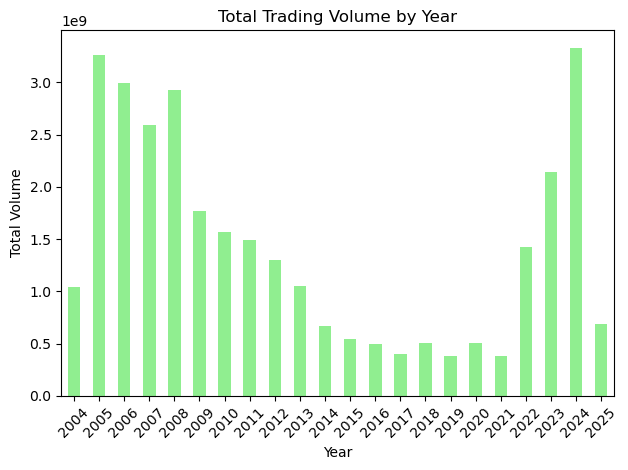

In [65]:
#  each bar repersent the year and heigt show how many shares of the google were bought and sold in that year
total_volume_year = df.groupby('year')['Volume'].sum()
total_volume_year.plot(kind='bar', color='lightgreen')
plt.title('Total Trading Volume by Year')
plt.xlabel('Year')
plt.ylabel('Total Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#  each bar repersent the year and heigt show how many shares of the google were bought and sold in that year
# insight:
#1)taller bars mean more people were trading the stock that year(high activity)
#2) smaller bars means few people trading the stock that year(low activity)
#resuit: by looking at the grahy i can say that 2024 year is having  more people trading  

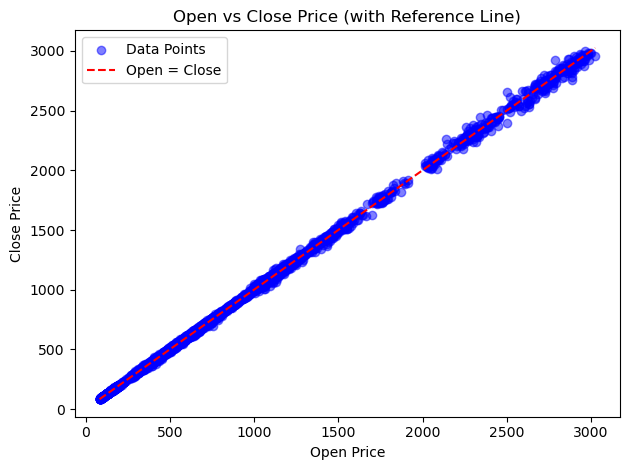

In [66]:
import matplotlib.pyplot as plt

plt.scatter(df['Open'], df['Close'], alpha=0.5, color='blue', label='Data Points')
# Diagonal reference line (where Open = Close)
min_val = min(df['Open'].min(), df['Close'].min())
max_val = max(df['Open'].max(), df['Close'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Open = Close')
plt.title('Open vs Close Price (with Reference Line)')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.legend()
plt.tight_layout()
plt.show()
# each dot is one day trading
# the red line show where there is no difference between the open and the close 
#insights
#1)if dots are close to red line the stock was stable
#2 if the dots are far from red line stock are volatile(big price jumps)
#3) if more points obove the line =market confidence
#4) more point below line =market drop days
# result
# most of the days the price increase at the end of the days but in many days the price remain same 
# the stock are often closed higher than opened (blue obove red line)so =gain at the end of day=upward trend  

In [81]:
import matplotlib.pyplot as plt


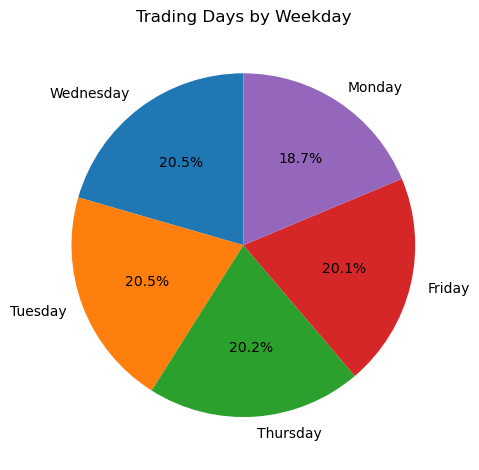

In [67]:
# plot pie chart

df['date'] = pd.to_datetime(df['date'])
df['weekday'] = df['date'].dt.day_name()
weekday_counts = df['weekday'].value_counts()
weekday_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Trading Days by Weekday')
plt.ylabel('') 
plt.tight_layout()
plt.show()
# result
# chart divide 5 slices monday to friday
# every slice show percentage of trading days that happen week days 
# conculation
#most trading(buy or sell stock) happened throughout the week but monday has few trading days due to holidays


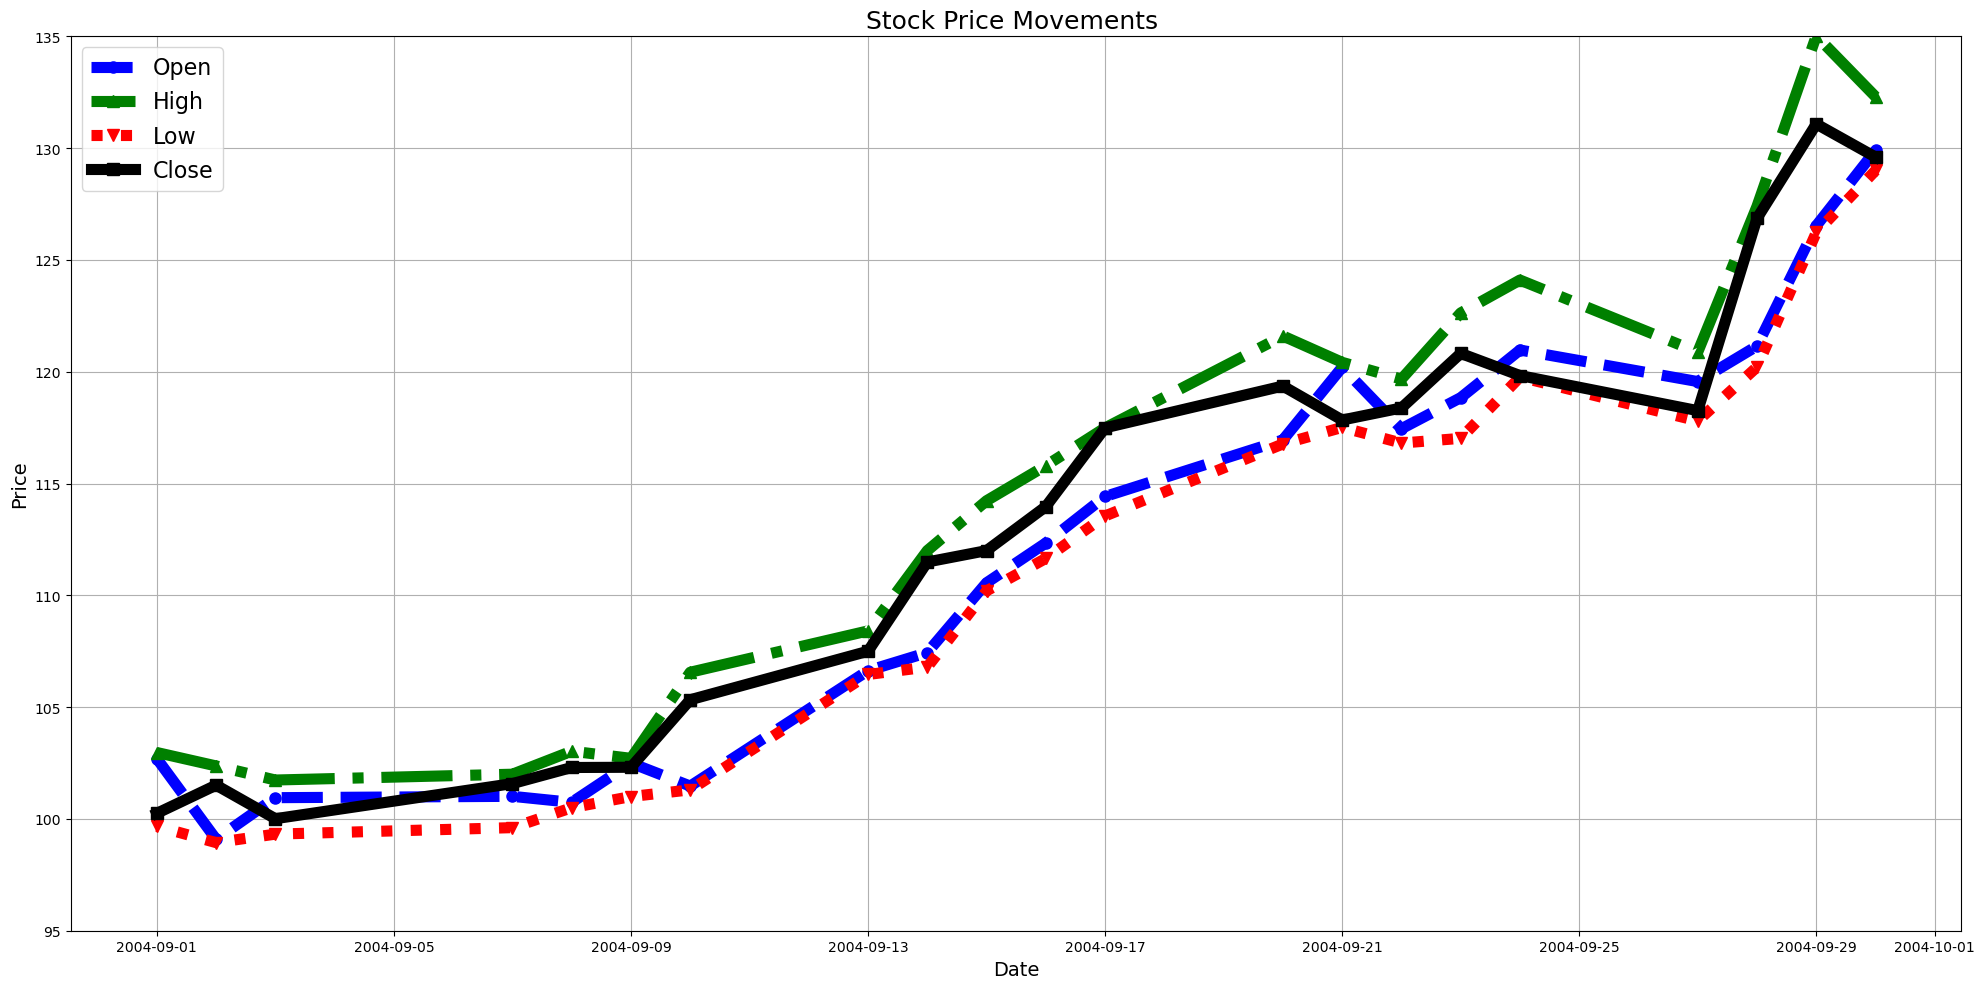

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plt.plot(df_short["date"], df_short["Open"], label="Open", color="blue", linestyle='--', linewidth=8, marker='o', markersize=8)
plt.plot(df_short["date"], df_short["High"], label="High", color="green", linestyle='-.', linewidth=8, marker='^', markersize=8)
plt.plot(df_short["date"], df_short["Low"], label="Low", color="red", linestyle=':', linewidth=8, marker='v', markersize=8)
plt.plot(df_short["date"], df_short["Close"], label="Close", color="black", linestyle='-', linewidth=8, marker='s', markersize=8)

plt.xlabel("Date", fontsize=14)
plt.ylabel("Price", fontsize=14)
plt.title("Stock Price Movements ", fontsize=18)

# Set y-axis limits to match Image 1 (showing the full range including low values)
plt.ylim(95, 135)

plt.grid(True)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

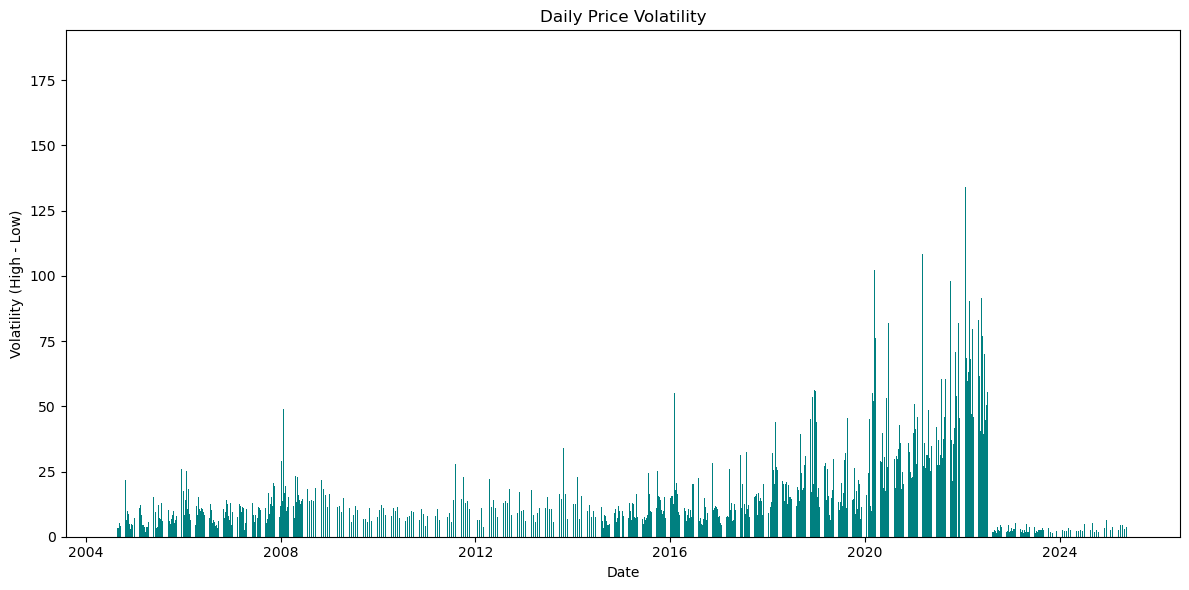

In [101]:

import matplotlib.pyplot as plt

df["date"] = pd.to_datetime(df["date"])

# Plot
plt.figure(figsize=(12, 6))
plt.bar(df["date"], df["Volatility"], color='teal')  # Just added width
plt.title("Daily Price Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (High - Low)")
plt.tight_layout()
plt.show()
#result
#1)the period 2004 2017 as bars are small low change of value (low volatility) = market is stable
#2) from this i can see from 2020 is 2022 increase in volatility
#3) after the year 2022 the volatility remain drop =reduced trading activity
#conculation: calm market = small changes,less risky
# show this market was calm ,active or risky

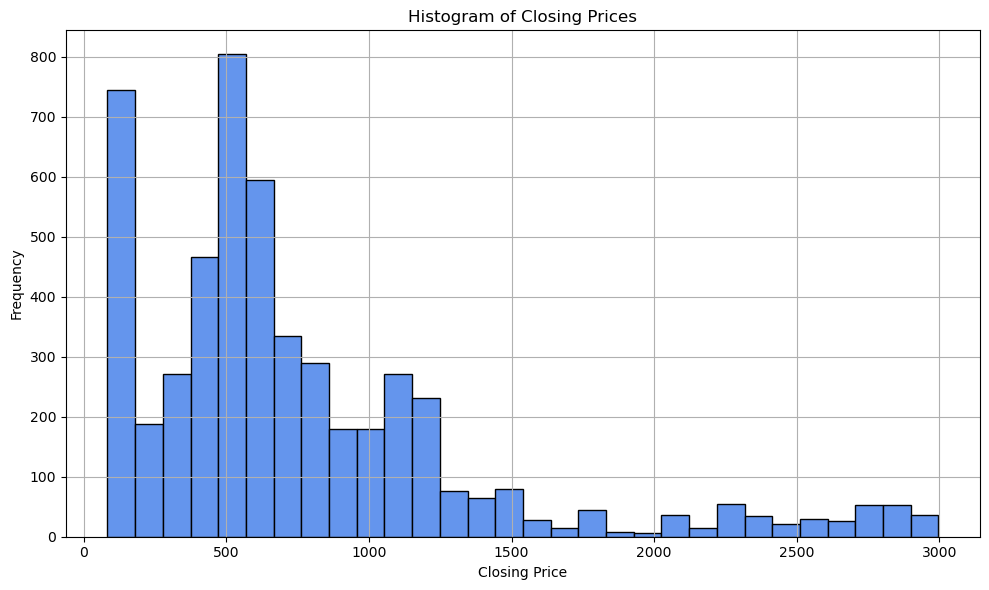

In [102]:


plt.figure(figsize=(10, 6))
plt.hist(df["Close"], bins=30, color='cornflowerblue', edgecolor='black')
plt.title("Histogram of Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()
# result
# there is peak near near 500
# most close prices are between 500 and 1000
# few occrance of high price like 1500,2000 etc
# there is right skewed (high price) is rare
# below the 500 showing earlier year stock are cheap
# conculation
#the stock remain in middle bec there is less high value

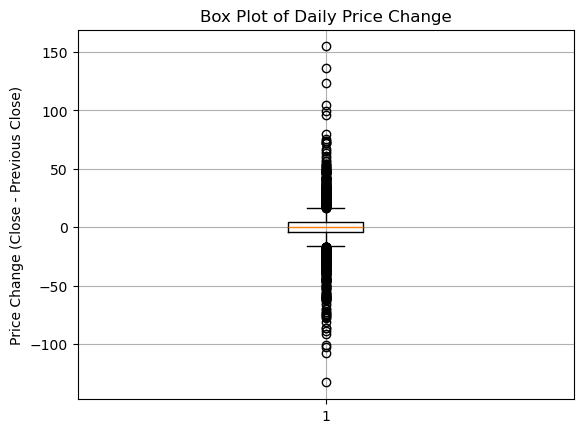

In [103]:
plt.boxplot(df["Price_change"])
plt.title("Box Plot of Daily Price Change")
plt.ylabel("Price Change (Close - Previous Close)")
plt.grid(True)
plt.show()
# result 
#1) in this orange line show (median)= close to (0) =mean market is stable most days small ups and down
#2) there many outliers (dots)= mean price change more than usual caused by global event e.g covid
#3) as therte are outliers positive and negative  =mean market fall and rise 
#conculation 
#most daily price are small but some days show big jumps due to events

In [104]:


# Assuming you have a 'Price_Change' column
Q1 = df['Price_change'].quantile(0.25)
Q3 = df['Price_change'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = df[(df['Price_change'] < lower_bound) | (df['Price_change'] > upper_bound)]

print("Number of outliers:", len(outliers))
print(outliers.head())


Number of outliers: 585
          date     Open     High        Low    Close     Volume  year  month  \
729 2022-07-12  2324.30  2339.48  2273.8044  2280.41  1497985.0  2022      7   
730 2022-07-11  2359.96  2359.96  2306.6100  2313.53  1562185.0  2022      7   
731 2022-07-08  2345.00  2393.70  2338.0250  2387.07  1911908.0  2022      7   
732 2022-07-07  2301.60  2383.79  2296.6700  2375.66  2046794.0  2022      7   
733 2022-07-06  2266.04  2311.79  2229.5200  2291.44  1871569.0  2022      7   

     day    weekday  Price_change  Pervious_closing_value Percent_Change  \
729   12    Tuesday        -43.89                 2227.07         -1.97%   
730   11     Monday        -46.43                 2280.41         -2.04%   
731    8     Friday         42.07                 2313.53          1.82%   
732    7   Thursday         74.06                 2387.07           3.1%   
733    6  Wednesday         25.40                 2375.66          1.07%   

     Volatility       MA_30  
729     

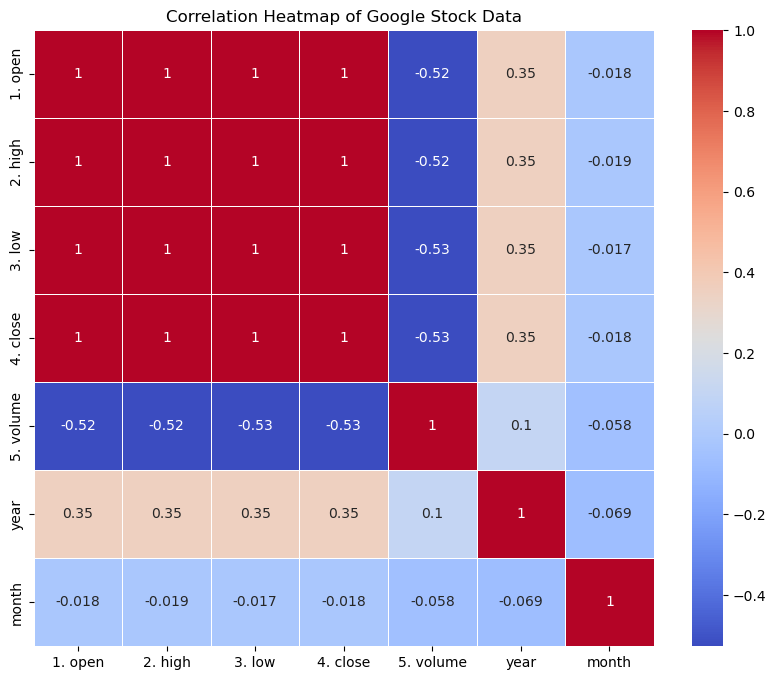

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your CSV file
df=pd.read_csv("googl_daily_prices.csv", encoding="ISO-8859-1")

# Convert the date column to datetime and extract year and month
df['date'] = pd.to_datetime(df['date'])  # Make sure 'date' column exists
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Select the exact columns used in the heatmap
cols_to_keep = ['1. open', '2. high', '3. low', '4. close', '5. volume', 'year', 'month']
numeric_df = df[cols_to_keep]

# Compute the correlation matrix
corr_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Google Stock Data")
plt.show()


In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Clean column names (remove whitespace)
df.columns = df.columns.str.replace(r'\s+', '', regex=True)

# Create derived columns manually
df['Price_change'] = df['4.close'] - df['1.open']
df['Volatility'] = df['2.high'] - df['3.low']

# Create target variable: 1 if price went up, else 0
df['Target'] = df['Price_change'].apply(lambda x: 1 if x > 0 else 0)

# Select features and labels
X = df[['Volatility']]
y = df['Target']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN model
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Predicted Labels:", y_pred[:10])
print("Actual Labels:   ", y_test.values[:10])


Accuracy: 0.5195797516714422
Confusion Matrix:
 [[262 240]
 [263 282]]
Predicted Labels: [0 0 1 1 0 1 1 1 1 1]
Actual Labels:    [1 1 0 1 1 0 0 0 0 0]


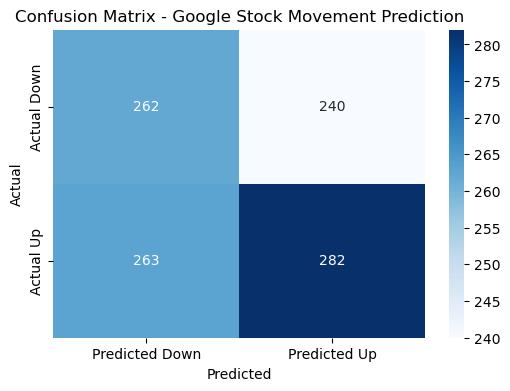

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it using seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Down', 'Predicted Up'], yticklabels=['Actual Down', 'Actual Up'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Google Stock Movement Prediction')
plt.show()


# Conclusion

In [ ]:
# conclusion on my project
#after cleaning and exploring the data i have applied the knn model using one feature the result does not 
#improve with different k showing underfitting we can further improve the result by using relevant features like 
#(close ,volumn)
#or trying more powerful model like logistic regression or decision tress